# Prithvi WxC Downscaling with CORDEX Data: Model Fine-tuning

This notebook demonstrates how to fine-tune the `Prithvi` downscaling model on CORDEX SA data.

We show how to set up the model, load the pretrained weights, and run finetuning using the CORDEX-derived inputs.

The datasets are from https://zenodo.org/records/17517423

---

## Setup

Python >= 3.10 is required

Make sure that your current working directory is `granite-wxc/`

In [1]:
import os
import sys
from pathlib import Path
REPO_ROOT = Path("d:\\granite-wxc").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir("d:\\granite-wxc\\examples\\CORDEX_ML")
print(f"Working directory set to: {Path.cwd()}")

Working directory set to: d:\granite-wxc\examples\CORDEX_ML


In [2]:
# ===================== CONFIGURATION / HARDWARE (EDIT ME) =====================
import os
import subprocess

enable_gpu_auto_select = True
min_free_mem_gb = 0.0
prefer_idle_gpus = True
max_gpus = 1  # expose one GPU for single-GPU training
force_visible_devices = None  # e.g. "0,1"
seed = 123
require_idle_gpu = False
idle_must_have_no_running_job = False
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("CORDEX_STRICT_VISIBLE_DEVICES", "0")  # allow single-GPU retries across visible GPUs
os.environ.setdefault("CORDEX_ALLOW_MULTI_GPU_FALLBACK", "0")
os.environ.setdefault("CORDEX_DISABLE_DISTRIBUTED_TO_SINGLE_FALLBACK", "1")
os.environ.setdefault("CORDEX_IDLE_REQUIRE_NO_COMPUTE_PROCESS", "0")
os.environ.setdefault("CORDEX_INCLUDE_BUSY_GPU_CANDIDATES", "1")
os.environ.setdefault("CORDEX_ALLOW_OOM_CROP_SHRINK", "0")
os.environ.setdefault("CORDEX_MAX_SINGLE_GPU_OOM_RETRIES", "8")
os.environ.setdefault("CORDEX_OOM_MIN_TRAIN_CROP_SIZE", "64")
resume_from_checkpoint = False
resume_checkpoint_override = None  # optional explicit checkpoint path


def _parse_device_list(value):
    if value is None:
        return []
    return [int(part.strip()) for part in str(value).split(",") if part.strip()]


def _query_gpu_stats():
    query = "index,memory.total,memory.used,utilization.gpu"
    try:
        out = subprocess.check_output(
            ["nvidia-smi", f"--query-gpu={query}", "--format=csv,noheader,nounits"],
            text=True,
        )
    except Exception as exc:
        print(f"GPU status query failed (nvidia-smi unavailable): {exc}")
        return []

    stats = []
    for raw in out.strip().splitlines():
        if not raw.strip():
            continue
        idx_str, total_str, used_str, util_str = [part.strip() for part in raw.split(",")]
        util_digits = "".join(ch for ch in util_str if ch.isdigit())
        total_mb = int(total_str)
        used_mb = int(used_str)
        util = int(util_digits) if util_digits else 100
        stats.append(
            {
                "index": int(idx_str),
                "total_mb": total_mb,
                "used_mb": used_mb,
                "free_mb": max(total_mb - used_mb, 0),
                "util": util,
            }
        )
    return stats


def _query_busy_gpu_indices():
    """Return physical GPU indices that currently run compute processes."""
    try:
        gpu_rows = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=index,uuid", "--format=csv,noheader,nounits"],
            text=True,
        )
    except Exception:
        return set()

    uuid_to_index = {}
    for raw in gpu_rows.strip().splitlines():
        row = raw.strip()
        if not row:
            continue
        parts = [part.strip() for part in row.split(",", 1)]
        if len(parts) != 2 or not parts[0].isdigit():
            continue
        uuid_to_index[parts[1]] = int(parts[0])

    try:
        proc_rows = subprocess.check_output(
            ["nvidia-smi", "--query-compute-apps=gpu_uuid,pid", "--format=csv,noheader,nounits"],
            text=True,
        )
    except Exception:
        return set()

    busy = set()
    for raw in proc_rows.strip().splitlines():
        row = raw.strip()
        if not row:
            continue
        parts = [part.strip() for part in row.split(",", 1)]
        if len(parts) != 2:
            continue
        gpu_uuid, pid = parts
        if not pid.isdigit():
            continue
        idx = uuid_to_index.get(gpu_uuid)
        if idx is not None:
            busy.add(idx)
    return busy


def _select_gpu_indices(gpu_stats, threshold_mb, prefer_idle, max_devices):
    busy = _query_busy_gpu_indices() if idle_must_have_no_running_job else set()

    def _rank_key(g):
        return (
            (g["index"] in busy) if prefer_idle else False,
            -g["free_mb"],
            g["util"],
            g["used_mb"],
            g["index"],
        )

    ranked = sorted(gpu_stats, key=_rank_key)
    selected = [
        g["index"]
        for g in ranked
        if (g["index"] not in busy) and g["free_mb"] >= threshold_mb
    ]
    if max_devices is not None:
        selected = selected[: int(max_devices)]
    return selected


def configure_gpu_hardware():
    gpu_stats = _query_gpu_stats()
    available = [g["index"] for g in gpu_stats]
    threshold_mb = int(float(min_free_mem_gb) * 1024)
    selected = []
    reason = ""
    forced = force_visible_devices is not None and str(force_visible_devices).strip() != ""

    if forced:
        os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
        os.environ["CUDA_VISIBLE_DEVICES"] = str(force_visible_devices)
        selected = _parse_device_list(force_visible_devices)
        reason = "force_visible_devices override applied."
    elif enable_gpu_auto_select and gpu_stats:
        selected = _select_gpu_indices(gpu_stats, threshold_mb, prefer_idle_gpus, max_gpus)
        if not selected:
            if require_idle_gpu:
                raise RuntimeError(
                    "No idle GPU was found (running compute process detected on all GPUs). "
                    "Free a GPU or set CORDEX_IDLE_REQUIRE_NO_COMPUTE_PROCESS=0."
                )
            selected = _select_gpu_indices(gpu_stats, 0, prefer_idle_gpus, 1)
            reason = (
                "No idle GPU was found; falling back to the best available single GPU."
            )
        else:
            reason = "Auto-selected idle GPUs (no running compute process)."
        os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
        os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(i) for i in selected)
    elif gpu_stats:
        selected = available[:] if max_gpus is None else available[: int(max_gpus)]
        os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
        os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(i) for i in selected)
        reason = "Auto-select disabled; using detected GPUs."
    else:
        reason = "No GPUs detected from nvidia-smi."

    if not gpu_stats:
        try:
            import torch  # fallback when nvidia-smi is unavailable

            count = torch.cuda.device_count()
        except Exception:
            count = 0
        if forced and selected:
            count = max(count, len(selected))
        if count > 0 and not forced:
            selected = list(range(count if max_gpus is None else min(count, int(max_gpus))))
            os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
            os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(i) for i in selected)
            reason = "nvidia-smi unavailable; using all torch-detected GPUs."
        elif count == 0 and not forced:
            selected = []

    if forced and selected and available:
        missing = [idx for idx in selected if idx not in available]
        if missing:
            print(f"Warning: forced GPU indices not detected by nvidia-smi: {missing}")

    selected_stats = {g["index"]: g for g in gpu_stats}
    use_gpu = len(selected) > 0
    world_size = len(selected) if use_gpu else 0
    strategy = "ddp" if world_size > 1 else ("single_gpu" if world_size == 1 else "cpu")

    print("Hardware summary:")
    print(f"  selected_original_gpus={selected}")
    print(f"  selected_visible_gpus={list(range(world_size)) if use_gpu else []}")
    if "CUDA_VISIBLE_DEVICES" in os.environ:
        print(f"  CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']}")
    if selected:
        for visible_idx, original_idx in enumerate(selected):
            stat = selected_stats.get(original_idx)
            if stat is None:
                print(f"  GPU orig={original_idx} vis={visible_idx}: stats unavailable")
                continue
            print(
                "  GPU orig={orig} vis={vis}: total={total:.1f}GB used={used:.1f}GB free={free:.1f}GB util={util}%".format(
                    orig=original_idx,
                    vis=visible_idx,
                    total=stat["total_mb"] / 1024.0,
                    used=stat["used_mb"] / 1024.0,
                    free=stat["free_mb"] / 1024.0,
                    util=stat["util"],
                )
            )
    else:
        print("  Warning: no usable GPUs selected; running on CPU.")
    print(f"  world_size={world_size}")
    print(f"  strategy={strategy}")
    if reason:
        print(f"  note={reason}")

    return {
        "selected_original_indices": selected,
        "world_size": world_size,
        "use_gpu": use_gpu,
        "strategy": strategy,
    }


GPU_SELECTION = configure_gpu_hardware()
SELECTED_GPU_ORIGINAL_IDS = GPU_SELECTION["selected_original_indices"]
SELECTED_GPU_COUNT = GPU_SELECTION["world_size"]
SELECTED_USE_GPU = GPU_SELECTION["use_gpu"]

try:
    import torch
    TORCH_CUDA_AVAILABLE = torch.cuda.is_available()
except Exception as exc:
    TORCH_CUDA_AVAILABLE = False
    print(f"Torch CUDA availability check failed: {exc}")

if SELECTED_USE_GPU and not TORCH_CUDA_AVAILABLE:
    print("GPU hardware was detected, but this Python environment has CPU-only PyTorch; using CPU.")
    SELECTED_GPU_ORIGINAL_IDS = []
    SELECTED_GPU_COUNT = 0
    SELECTED_USE_GPU = False
    os.environ.pop("CUDA_VISIBLE_DEVICES", None)


Hardware summary:
  selected_original_gpus=[0]
  selected_visible_gpus=[0]
  CUDA_VISIBLE_DEVICES=0
  GPU orig=0 vis=0: total=95.6GB used=3.2GB free=92.4GB util=3%
  world_size=1
  strategy=single_gpu
  note=Auto-selected idle GPUs (no running compute process).


## GPU Selection Notes

- Set `force_visible_devices` (for example `"1"` or `"0,2"`) to bypass auto-selection and use those original GPU IDs.
- With auto-selection enabled, GPUs are ranked by highest free memory, then lowest utilization, then lowest used memory.
- `min_free_mem_gb` is the free-memory threshold. If no GPU meets it, the notebook falls back to all detected GPUs (or CPU if none are available).
- `max_gpus` caps how many selected GPUs are exposed through `CUDA_VISIBLE_DEVICES`.


In [3]:
# ===================== USER PARAMETERS (EDIT ME) =====================
from sa_params import UserParams, validate_paths


PROJECT_DIR = REPO_ROOT / "examples/CORDEX_ML"
DATASET_ROOT = Path("d:\\CORDEX\\SA_domain")

TRAIN_SPLIT = "train/Emulator_hist_future"
PREDICTOR_FILE = "ACCESS-CM2_1961-1980_2080-2099_regridded.nc"
TARGET_FILE = "pr_tasmax_ACCESS-CM2_1961-1980_2080-2099.nc"

TRAIN_PREDICTORS = [DATASET_ROOT / TRAIN_SPLIT / "predictors" / PREDICTOR_FILE]
TRAIN_TARGETS = [DATASET_ROOT / TRAIN_SPLIT / "target" / TARGET_FILE]
STATIC_PATH = DATASET_ROOT / TRAIN_SPLIT / "predictors" / "Static_fields.nc"

RUN_NAME_OVERRIDE = None  # use config.job_id from the YAML by default
USE_STATIC = True  # set False to ignore static/orography inputs

P = UserParams(
    repo_root=REPO_ROOT,
    project_dir=PROJECT_DIR,
    runs_root=PROJECT_DIR / "runs/SA_T2_ACCESS-CM2_static_train",
    # Integrated two-phase YAML: Phase 1 (U-Net) then Phase 2 (diffusion head).
    # Edit the two_phase_training block in that file to adjust epochs / lr.
    config_path=PROJECT_DIR / "SA_T2_ACCESS-CM2_static_twophase.yaml",
    run_name=RUN_NAME_OVERRIDE,
    train_predictor_paths=TRAIN_PREDICTORS,
    train_target_paths=TRAIN_TARGETS,
    val_predictor_paths=TRAIN_PREDICTORS,
    val_target_paths=TRAIN_TARGETS,
    test_predictor_paths=TRAIN_PREDICTORS,
    test_target_paths=TRAIN_TARGETS,
    use_static=USE_STATIC,
    device_target="cuda" if SELECTED_USE_GPU else "cpu",
    batch_size=1,
    num_workers=2,
    preferred_checkpoint="best",
)

validate_paths(P)


If your current directory is not `granite-wxc/`, change it using the following command:

```bash
%cd <local>/granite-wxc/
```

Replace `<local>` with the appropriate path prefix 

In [4]:
import importlib
if importlib.util.find_spec("PrithviWxC") is None:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "git+https://github.com/NASA-IMPACT/Prithvi-WxC.git"])

In [5]:
import os
import logging
import warnings

logging.disable(logging.CRITICAL)
warnings.simplefilter(action='ignore', category=FutureWarning)

os.chdir(P.project_dir)
print(f"Project directory set to: {os.getcwd()}")

Project directory set to: D:\granite-wxc\examples\CORDEX_ML


In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.distributed import DistributedSampler

from cordex_dataset import CordexDownscaleDataset
from cordex_training import (
    get_dataloaders as build_cordex_dataloaders,
    create_finetune_model,
    run_training as launch_cordex_training,
)
from granitewxc.utils.config import get_config
from granitewxc.utils.distributed import init_ddp
from granitewxc.models.model import get_finetune_model_UNET, get_finetune_model
from granitewxc.utils.plot import plot_loss


In [7]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

from cordex_dataset import CordexDownscaleDataset
from granitewxc.utils.config import get_config
from granitewxc.utils.distributed import init_ddp
from granitewxc.models.model import get_finetune_model_UNET, get_finetune_model
from granitewxc.utils.plot import plot_loss

Run setup utilities from `examples/CORDEX_ML/run_utils.py` are imported below and rely on the repository path specified in the parameter cell.

In [8]:
torch.jit.enable_onednn_fusion(True)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True
torch.manual_seed(seed)


It is possible to use a cpu or gpu/s to generate inferences. Based on avaiablity of a `cuda:gpu`, we set the device that the model uses

In [9]:
target = (getattr(P, 'device_target', 'auto') or 'auto').lower()
if target == 'cuda':
    if not torch.cuda.is_available():
        raise RuntimeError("device_target is 'cuda' but no CUDA device is available.")
    device = torch.device('cuda')
    use_gpu = True
elif target == 'cpu':
    device = torch.device('cpu')
    use_gpu = False
else:
    if torch.cuda.is_available():
        device = torch.device('cuda')
        use_gpu = True
    else:
        device = torch.device('cpu')
        use_gpu = False


In [10]:
print(device)

cuda


We initialize the Distributed Data Parallel (DDP) environment to leverage multiple GPUs for training

In [11]:
from pathlib import Path

config_path = P.config_path
config = get_config(str(config_path))

# YAML paths are repository-root-relative, while this notebook runs from
# examples/CORDEX_ML. Resolve scalar sources before copying or loading them.
def _resolve_repo_file(path_value):
    path = Path(path_value).expanduser()
    if not path.is_absolute():
        path = P.repo_root / path
    path = path.resolve()
    if not path.is_file():
        raise FileNotFoundError(f"Required scalar file does not exist: {path}")
    return str(path)

for scalar_attr in ("input_mu", "input_sigma", "target_mu", "target_sigma"):
    setattr(config.model, scalar_attr, _resolve_repo_file(getattr(config.model, scalar_attr)))
if isinstance(getattr(config.data, "scalers", None), dict):
    config.data.scalers = {
        name: _resolve_repo_file(path) for name, path in config.data.scalers.items()
    }

# Keep precipitation distribution/loss parameters in the YAML as the source
# of truth. Only legacy hurdle configs need these compatibility defaults.
config.precip_model = str(getattr(config, "precip_model", "single_head"))
if config.precip_model.strip().lower() == "hurdle":
    config.precip_wet_threshold = float(getattr(config, "precip_wet_threshold", 0.5))
    config.precip_lambda_occurrence = float(getattr(config, "precip_lambda_occurrence", 1.0))
    config.precip_lambda_amount = float(getattr(config, "precip_lambda_amount", 1.0))
    config.precip_amount_loss_type = str(getattr(config, "precip_amount_loss_type", "smoothl1"))
config.device_target = getattr(P, 'device_target', config.device_target)
config.run_single_gpu_in_process = True  # keep tqdm/progress output visible in this notebook
def _as_bool(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        return bool(value)
    if isinstance(value, str):
        return value.strip().lower() in {"1", "true", "yes", "on"}
    return bool(value)
resume_flag = _as_bool(resume_from_checkpoint)
config.resume_training = resume_flag
config.auto_resume_if_checkpoint_exists = resume_flag
if config.resume_training and resume_checkpoint_override:
    config.resume_checkpoint_path = str(resume_checkpoint_override)
elif not config.resume_training:
    config.resume_checkpoint_path = None
original_num_gpus = int(getattr(getattr(config, "training", None), "num_gpus", getattr(config, "num_gpus", 1)) or getattr(config, "num_gpus", 1) or 1)
original_per_device_batch = int(getattr(getattr(config, "training", None), "per_device_batch_size", getattr(config, "batch_size", 1)) or getattr(config, "batch_size", 1) or 1)
original_grad_accum = int(getattr(getattr(config, "training", None), "gradient_accumulation_steps", getattr(config, "gradient_accumulation_steps", 1)) or getattr(config, "gradient_accumulation_steps", 1) or 1)
original_effective_batch_size = max(1, original_num_gpus * original_per_device_batch * original_grad_accum)
if use_gpu:
    if not SELECTED_USE_GPU:
        raise RuntimeError("GPU training requested but no idle GPUs were selected.")
    requested_world_size = 1
    config.num_gpus = 1
    config.distributed_strategy = "none"
    config.allow_distributed_single_gpu_fallback = True
    if hasattr(config, "training"):
        try:
            config.training.num_gpus = 1
            config.training.distributed = "none"
            config.training.allow_distributed_single_gpu_fallback = True
        except Exception:
            pass
else:
    config.num_gpus = 0
    config.distributed_strategy = "none"
    config.allow_distributed_single_gpu_fallback = True
    if hasattr(config, "training"):
        try:
            config.training.num_gpus = 0
            config.training.distributed = "none"
            config.training.allow_distributed_single_gpu_fallback = True
        except Exception:
            pass
# OOM guardrails for notebook launches
config.batch_size = 1
config.dl_num_workers = 0
config.dl_prefetch_size = 0
config.dl_pin_memory = False
config.pin_memory = False
config.backbone_gradient_checkpointing = True
config.skip_activation_offload = True
if hasattr(config, "training"):
    try:
        cfg_per_device = int(getattr(config.training, "per_device_batch_size", 1) or 1)
        config.training.per_device_batch_size = max(1, cfg_per_device)
        config.batch_size = max(1, cfg_per_device)
    except Exception:
        pass
    try:
        target_num_gpus_for_effective = int(getattr(config.training, "num_gpus", getattr(config, "num_gpus", 1)) or 1)
        denom = max(1, cfg_per_device * target_num_gpus_for_effective)
        cfg_accum = max(1, int(round(original_effective_batch_size / denom)))
        config.training.gradient_accumulation_steps = cfg_accum
        config.gradient_accumulation_steps = cfg_accum
        effective_after = cfg_per_device * target_num_gpus_for_effective * cfg_accum
        if effective_after != original_effective_batch_size:
            print(
                f"[batch] adjusted grad_accum={cfg_accum} for num_gpus={target_num_gpus_for_effective}; "
                f"effective batch {original_effective_batch_size} -> {effective_after}."
            )
    except Exception:
        pass
    try:
        prev_retry = int(getattr(config.training, "max_single_gpu_oom_retries", 0) or 0)
        config.training.max_single_gpu_oom_retries = max(prev_retry, 8)
    except Exception:
        pass
if getattr(P, "use_static", None) is not None:
    config.data.use_static = bool(P.use_static)
if bool(getattr(config.data, "use_static", False)):
    config.data.static_path = str(STATIC_PATH.resolve())

def _override(attr: str, values):
    if values:
        setattr(config.data, attr, [str(Path(p).resolve()) for p in values])

_override('training_predictor_paths', P.train_predictor_paths)
_override('training_target_paths', P.train_target_paths)
if _as_bool(getattr(config, 'validation_enabled', True)):
    _override('validation_predictor_paths', P.val_predictor_paths)
    _override('validation_target_paths', P.val_target_paths)
else:
    config.data.validation_predictor_paths = []
    config.data.validation_target_paths = []
_override('test_predictor_paths', P.test_predictor_paths)
_override('test_target_paths', P.test_target_paths)

if P.batch_size is not None:
    config.batch_size = int(P.batch_size)
if P.num_workers is not None:
    config.dl_num_workers = int(P.num_workers)

# Keep geometry fixed for comparable results
config.data.train_crop_size_lat = int(config.data.target_size_lat)
config.data.train_crop_size_lon = int(config.data.target_size_lon)
config.data.val_crop_size_lat = int(config.data.target_size_lat)
config.data.val_crop_size_lon = int(config.data.target_size_lon)

train_dl, val_dl = build_cordex_dataloaders(config, use_gpu)
len(train_dl), (len(val_dl) if val_dl is not None else 0)


[data] validation disabled; using 100% of the configured training sources with no validation loader or holdout.


D:\granite-wxc\examples\CORDEX_ML\cordex_dataset.py:510: RuntimeWarning: xESMF could not be imported; falling back to xarray interpolation (ModuleNotFoundError: No module named 'xesmf').
  warnings.warn(


[data] random_crop requested but disabled because crop_size=128x128 covers full grid 128x128. Set data.train_crop_size_lat/lon smaller than the target grid to enable crop augmentation.


(14600, 0)

## Configuration File

The model is configured using `YAML` files.

In these files, you specify:
- Paths to the input data  
- Locations of the pretrained weights  

To ensure compatibility with the provided weights during inference, keep the model configuration consistent with the original definitions 

In [12]:
import importlib, importlib.metadata
try:
    importlib.metadata.requires("granitewxc")  # raises PackageNotFoundError if not installed
except importlib.metadata.PackageNotFoundError:
    import os, subprocess, sys
    os.chdir(P.repo_root)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", "."])
    os.chdir(P.project_dir)

In [13]:
# Configuration already loaded using the USER PARAMETERS block.

In [14]:
# Working directory managed via the parameter cell.

In [15]:
from datetime import datetime
from pathlib import Path

from run_utils import (
    copy_scalars_to_run,
    prepare_run_paths,
    snapshot_resolved_config,
    update_manifest,
    write_manifest,
)
from sa_params import resolve_run_dir, export_params

RUN_NAME, resolved_run_dir = resolve_run_dir(P, config)
run_paths = prepare_run_paths(Path(P.runs_root), RUN_NAME)
assert run_paths.run_dir == resolved_run_dir

config.path_experiment = str(run_paths.run_dir)
config.checkpoint_dir = str(run_paths.checkpoints)
config.scalar_dir = str(run_paths.scalars)
config.preproc_dir = str(run_paths.preproc)
if not resume_flag:
    stale_ckpts = sorted(Path(config.checkpoint_dir).glob("*.ckpt"))
    if stale_ckpts:
        for ckpt in stale_ckpts:
            ckpt.unlink()
        print(f"Cleared {len(stale_ckpts)} stale checkpoint(s) from {config.checkpoint_dir} for a fresh run.")

scalar_records = copy_scalars_to_run(config, run_paths.scalars)
resolved_config_path = snapshot_resolved_config(
    config, run_paths.config_dir / "resolved.yaml"
)
manifest = write_manifest(
    run_paths,
    run_name=RUN_NAME,
    base_config=str(config_path),
    resolved_config=resolved_config_path,
    scalars=scalar_records,
)

params_json = export_params(P, run_paths.run_dir / "params.json", extra={"run_name": RUN_NAME})
print(f"Run artifacts will be stored in {run_paths.run_dir}")
print(f"Config snapshot: {resolved_config_path}")
print(f"Saved parameter snapshot to {params_json}")

Run artifacts will be stored in D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase
Config snapshot: D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\config\resolved.yaml
Saved parameter snapshot to D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\params.json


## Dataloader 

In this CORDEX example we will use a single regridded data pair for both training and validation.

In [16]:
# This cell is deprecated; please use the helper functions defined earlier for dataloaders.


### Sample shapes

We check the batched tensor shapes from the CORDEX dataloader.

In [17]:
example_batch = next(iter(train_dl))
if "static_x" in example_batch:
    example_batch["x"].shape, example_batch["y"].shape, example_batch["static_x"].shape
else:
    example_batch["x"].shape, example_batch["y"].shape


In [18]:
target_shape = tuple(example_batch["y"].shape)
var_names = list(config.data.output_vars)
print(f"Configured output variables: {var_names}")
print(f"Sample target tensor shape: {target_shape}")
if target_shape[1] != len(var_names):
    raise ValueError(
        f"Dataloader returned {target_shape[1]} channels but config specifies {len(var_names)}"
    )
missing_expected = {"pr", "tasmax"} - set(var_names)
if missing_expected:
    raise ValueError(f"Missing expected SA targets: {sorted(missing_expected)}")
print("Fine-tuning includes both 'pr' and 'tasmax'.")


Configured output variables: ['pr', 'tasmax']
Sample target tensor shape: (1, 2, 128, 128)
Fine-tuning includes both 'pr' and 'tasmax'.


## Model Initialization

We provide **2** different model architectures `UNET-like` and `CONV` 

Both architectures include:  
1. **Patch Embedding**: Extracts shallow features from the input data  
2. **Feature Extraction**: Utilizes the Prithvi backbone to extract deeper features  

The key difference is that the UNET-like version incorporates **static high-resolution data** into the model

In this notebook, we use the **UNET-like** version

To switch to the **CONV** model, update the configuration file accordingly and use `get_finetune_model(config)` 

In [19]:
model = create_finetune_model(config).to(device)


[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] resolved training output configuration:
  - pr: allow_negative_value=False, nonnegativity=(True, softplus), scaling=(divide_only, p95)
  - tasmax: allow_negative_value=False, nonnegativity=(False, none), scaling=(zscore, mean)
Creating the model.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> model has 246,408,968 params.
Loaded 15 tensors from ./granite-geospatial-wxc-downscaling/ECCC/weights/best_rmse_UNET.pt. Skipped 193 mismatched entries.


c:\Users\huikyole\AppData\Local\miniforge3\envs\Prithvi\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(


We can now load the pretrained weights

In [20]:
# Pretrained weights are loaded via create_finetune_model().


## Finetuning

The model is now ready for training

In [21]:
from torch.optim import AdamW
from torch.cuda.amp import GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

from granitewxc.utils.trainer import train_model
try:
    from granitewxc.models.loss import rmse_loss
except ModuleNotFoundError:
    import torch

    def rmse_loss(y_hat, y):
        return torch.sqrt(torch.mean((y_hat - y['y']) ** 2))

## 
Defining the optimizer, scaler, and scheduler for the training process.

In [22]:
# Optimizer configuration handled inside cordex_training.run_training.


We'll train the model using just 1 data pair and run it for only 5 epochs

Let's train it for a couple of epochs based on the configuration file

In [23]:
try:
    result = launch_cordex_training(config, num_gpus=(1 if (use_gpu and SELECTED_USE_GPU) else 0), save_every=1)
    # Two-phase training returns (p1_train, p1_val, p2_train, p2_val).
    # Single-phase training returns (train_losses, val_losses).
    if len(result) == 4:
        p1_train_losses, p1_val_losses, train_losses, val_losses = result
        print(f"Phase 1 final train loss: {p1_train_losses[-1]:.4f}" if p1_train_losses else "Phase 1: no losses recorded.")
        print(f"Phase 2 final train loss: {train_losses[-1]:.4f}" if train_losses else "Phase 2: no losses recorded.")
    else:
        train_losses, val_losses = result
except Exception as exc:
    print(f"Training failed: {exc}")
    raise


[training] two_phase_training detected; running integrated U-Net → diffusion pipeline.
[two-phase] running in-process (notebook mode).

[two-phase] ═══ Phase 1: U-Net domain adaptation ═══
[data] validation disabled; using 100% of the configured training sources with no validation loader or holdout.
[data] random_crop requested but disabled because crop_size=128x128 covers full grid 128x128. Set data.train_crop_size_lat/lon smaller than the target grid to enable crop augmentation.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] resolved training output configuration:
  - pr: allow_negative_value=False, nonnegativity=(True, softplus), scaling=(divide_only, p95)
  - tasmax: allow_negative_value=False, nonnegativity=(False, none), scaling=(zscore, mean)
Creating the model.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like va

D:\granite-wxc\examples\CORDEX_ML\cordex_dataset.py:510: RuntimeWarning: xESMF could not be imported; falling back to xarray interpolation (ModuleNotFoundError: No module named 'xesmf').
  warnings.warn(


[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> model has 246,408,968 params.
Loaded 15 tensors from ./granite-geospatial-wxc-downscaling/ECCC/weights/best_rmse_UNET.pt. Skipped 193 mismatched entries.
[loss] phase 1 active: {'base': 'rmse', 'predictands': {'tasmax': {'enabled': True, 'method': 'cdf', 'weight': 0.05, 'use_mean': True, 'use_std': True, 'use_skewness': False, 'quantiles': [0.1, 0.5, 0.9], 'bins': 100, 'cdf_temperature': 0.05}}, 'spatial_gradient': {'enabled': True, 'weight': 0.03, 'predictands': {'pr': 0.25, 'tasmax': 1.0}, 'precipitation_wet_only': True, 'precipitation_wet_threshold': 0.1}, 'tv': {'enabled': False, 'weight': 0.0005, 'predictands': {'pr': 0.1, 'tasmax': 0.3}}, 'multiscale': {'enabled': True, 'weight': 0.015, 'scales': [2, 4], 'loss_type': 'l1'}, 'boundary_continuity': {'enabled': True, 'weight': 0.01, 'predictands': {'pr': 0.2, 'tasmax': 1.0}, 'stride_lat': 16, 'stride

Training Epoch 1/10: 100%|██████████| 14600/14600 [1:07:40<00:00,  3.60batch/s, base.rmse=7.19, loss=7.26, lr=9.76e-5, tasmax.distribution.cdf=0.000639]


[early_stopping] epoch 1: loss=7.00781, best=7.00781, no_improve=0/5
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> saved D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\phase1_unet\epoch_001.ckpt
--> saved D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\phase1_unet\last.ckpt
Learning rate: 9.75772975566101e-05
Rank 0 starting epoch 2...


...

[early_stopping] epoch 20: loss=5.10212, best=5.09211, no_improve=8/10
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> saved D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\phase2_diffusion\last.ckpt
Learning rate: 5.67908363781375e-06
Rank 0 starting epoch 21...


Training Epoch 21/25: 100%|██████████| 14600/14600 [35:35<00:00,  6.84batch/s, deterministic.base.rmse=2.57, eps_mse=0.00726, loss=2.61, lr=4.03e-6]  


[early_stopping] epoch 21: loss=5.09118, best=5.09211, no_improve=9/10
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> saved D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\phase2_diffusion\last.ckpt
Learning rate: 4.030486338925355e-06
Rank 0 starting epoch 22...


Training Epoch 22/25: 100%|██████████| 14600/14600 [37:25<00:00,  6.50batch/s, deterministic.base.rmse=13.3, eps_mse=0.0474, loss=13.5, lr=2.72e-6]   


[early_stopping] epoch 22: loss=5.09167, best=5.09211, no_improve=10/10
[early_stopping] stopping at epoch 22: no improvement > 0.01 for 10 consecutive epochs.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> saved D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\phase2_diffusion\last.ckpt
[two-phase] Phase 2 complete. Checkpoint: D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\phase2_diffusion
[two-phase] copied last.ckpt → D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\last.ckpt
Phase 1 final train loss: 5.0536
Phase 2 final train loss: 5.0917


In [24]:
from pathlib import Path

checkpoint_info = {
    "best": str(Path(config.checkpoint_dir) / "best.ckpt"),
    "latest_epoch": str(Path(config.checkpoint_dir) / "epoch_*.ckpt"),
}
manifest = update_manifest(run_paths.run_dir, checkpoints=checkpoint_info)
print("Updated run manifest with checkpoint locations:")
for label, ckpt_path in checkpoint_info.items():
    print(f"  {label}: {ckpt_path}")


Updated run manifest with checkpoint locations:
  best: D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\best.ckpt
  latest_epoch: D:\granite-wxc\examples\CORDEX_ML\runs\SA_T2_ACCESS-CM2_static_train\SA_T2_ACCESS-CM2_static_twophase\checkpoints\epoch_*.ckpt


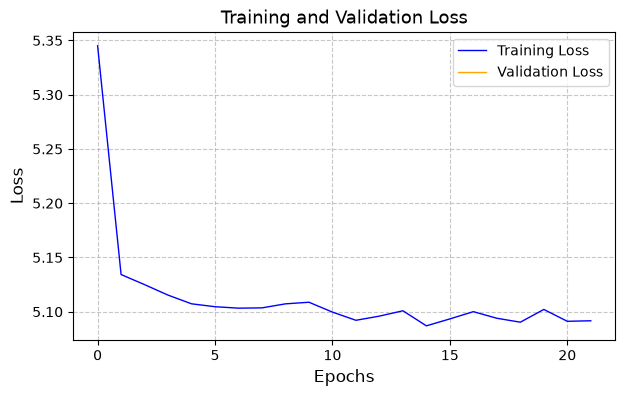

In [25]:
plot_loss(train_losses, val_losses)